# Online News Popularity Classification - Part 1

## Classification Algorithms Implemented:
1. **Logistic Regression**
2. **Naive Bayes**
3. **Decision Tree Classifier**

This notebook uses PySpark MLlib to predict online news article popularity using a binary classification approach with rolling window time-series validation.

In [1]:
# Import required libraries
import os

from pyspark.sql import SparkSession
from pyspark.sql.functions import when, col
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.classification import LogisticRegression, NaiveBayes, DecisionTreeClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.ml.tuning import TrainValidationSplit, ParamGridBuilder
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import roc_curve, auc

# Initialize Spark Session
spark = SparkSession.builder \
    .appName("NewsPopularityClassification_3CFU") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

print(f"Spark Version: {spark.version}")
print("Spark Session initialized successfully!")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/01/27 22:17:52 WARN Utils: Your hostname, Habibs-MacBook-Air.local, resolves to a loopback address: 127.0.0.1; using 10.205.192.217 instead (on interface en0)
26/01/27 22:17:52 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/01/27 22:17:53 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark Version: 4.1.1
Spark Session initialized successfully!


## 1. Data Loading and Exploration

In [2]:
# Load the dataset
data = spark.read.csv("OnlineNewsPopularity.csv", header=True, inferSchema=True)

# Clean column names immediately (remove leading/trailing spaces)
for col_name in data.columns:
    new_col = col_name.strip()
    if new_col != col_name:
        data = data.withColumnRenamed(col_name, new_col)

print(f"Total number of articles: {data.count()}")
print(f"Number of features: {len(data.columns)}")
print("\nSchema:")
data.printSchema()

Total number of articles: 39644
Number of features: 61

Schema:
root
 |-- url: string (nullable = true)
 |-- timedelta: double (nullable = true)
 |-- n_tokens_title: double (nullable = true)
 |-- n_tokens_content: double (nullable = true)
 |-- n_unique_tokens: double (nullable = true)
 |-- n_non_stop_words: double (nullable = true)
 |-- n_non_stop_unique_tokens: double (nullable = true)
 |-- num_hrefs: double (nullable = true)
 |-- num_self_hrefs: double (nullable = true)
 |-- num_imgs: double (nullable = true)
 |-- num_videos: double (nullable = true)
 |-- average_token_length: double (nullable = true)
 |-- num_keywords: double (nullable = true)
 |-- data_channel_is_lifestyle: double (nullable = true)
 |-- data_channel_is_entertainment: double (nullable = true)
 |-- data_channel_is_bus: double (nullable = true)
 |-- data_channel_is_socmed: double (nullable = true)
 |-- data_channel_is_tech: double (nullable = true)
 |-- data_channel_is_world: double (nullable = true)
 |-- kw_min_min: 

In [3]:
# Display basic statistics
print("Sample data:")
data.show(5)

print("\nShares distribution:")
data.select("shares").describe().show()

Sample data:


26/01/27 22:18:00 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+--------------------+---------+--------------+----------------+---------------+----------------+------------------------+---------+--------------+--------+----------+--------------------+------------+-------------------------+-----------------------------+-------------------+----------------------+--------------------+---------------------+----------+----------+----------+----------+----------+----------+----------+----------+----------+-------------------------+-------------------------+--------------------------+-----------------+------------------+--------------------+-------------------+-----------------+-------------------+-----------------+----------+---------------+---------------+---------------+---------------+---------------+-------------------+-------------------------+--------------------------+--------------------------+-------------------+-------------------+---------------------+---------------------+---------------------+---------------------+---------------------+----

## 2. Data Preprocessing

### 2.1 Binary Label Creation
Using threshold of 1,400 shares as per the original paper.

In [4]:
# Create binary label: 1 if shares > 1400, 0 otherwise
data = data.withColumn("label", when(col("shares") > 1400, 1).otherwise(0))

# Check class distribution
print("Class distribution:")
data.groupBy("label").count().show()

# Calculate class percentages
total = data.count()
popular = data.filter(col("label") == 1).count()
unpopular = data.filter(col("label") == 0).count()
print(f"Popular (>1400 shares): {popular} ({popular/total*100:.2f}%)")
print(f"Unpopular (<=1400 shares): {unpopular} ({unpopular/total*100:.2f}%)")

Class distribution:
+-----+-----+
|label|count|
+-----+-----+
|    1|19562|
|    0|20082|
+-----+-----+

Popular (>1400 shares): 19562 (49.34%)
Unpopular (<=1400 shares): 20082 (50.66%)


### 2.2 Feature Selection

In [5]:
# Define feature columns (exclude url, timedelta, shares, and label)
# timedelta is kept for sorting but excluded from features
exclude_cols = ["url", "timedelta", "shares", "label"]
feature_cols = [col for col in data.columns if col not in exclude_cols]

print(f"Number of feature columns: {len(feature_cols)}")
print(f"Feature columns: {feature_cols[:10]}...")  # Show first 10

Number of feature columns: 58
Feature columns: ['n_tokens_title', 'n_tokens_content', 'n_unique_tokens', 'n_non_stop_words', 'n_non_stop_unique_tokens', 'num_hrefs', 'num_self_hrefs', 'num_imgs', 'num_videos', 'average_token_length']...


### 2.3 Feature Vectorization

**Note on Scaling**: Features are vectorized here but NOT scaled yet. Scaling will be applied separately within each rolling window to prevent data leakage (scaler fitted on train only).

In [6]:
# Assemble features into a single vector (but don't scale yet!)
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
assembled_data = assembler.transform(data)

# Select only necessary columns (features are unscaled at this point)
# Scaling will be done separately for each rolling window to prevent data leakage
prepared_data = assembled_data.select("timedelta", "features", "label")

print("Feature assembly complete!")
print(f"Prepared data count: {prepared_data.count()}")
print("Note: Scaling will be applied separately within each rolling window to prevent data leakage")
prepared_data.show(5)

Feature assembly complete!
Prepared data count: 39644
Note: Scaling will be applied separately within each rolling window to prevent data leakage
+---------+--------------------+-----+
|timedelta|            features|label|
+---------+--------------------+-----+
|    731.0|(58,[0,1,2,3,4,5,...|    0|
|    731.0|(58,[0,1,2,3,4,5,...|    0|
|    731.0|(58,[0,1,2,3,4,5,...|    1|
|    731.0|(58,[0,1,2,3,4,5,...|    0|
|    731.0|(58,[0,1,2,3,4,5,...|    0|
+---------+--------------------+-----+
only showing top 5 rows


## 3. Rolling Window Time-Series Split

Following the paper's methodology:
- Window size (W) = 10,000 samples
- Step size (L) = 1,000 samples
- Train/Test split = 70/30 within each window

In [7]:
# Sort data by timedelta in DESCENDING order (chronological: oldest → newest)
# timedelta = days between publication and acquisition
# Large timedelta = old articles (published long ago)
# Small timedelta = new articles (published recently)
# We want: old → new (past → future) for time-series prediction
sorted_data = prepared_data.orderBy(col("timedelta").desc())

# Cache the sorted data for efficiency
sorted_data.cache()

# Parameters from the paper
W = 10000  # Window size
L = 1000   # Step size
total_rows = sorted_data.count()

print(f"Total samples: {total_rows}")
print(f"Window size (W): {W}")
print(f"Step size (L): {L}")

# Calculate number of windows
num_windows = (total_rows - W) // L + 1
print(f"Number of rolling windows: {num_windows}")

Total samples: 39644
Window size (W): 10000
Step size (L): 1000
Number of rolling windows: 30


In [8]:
print("Creating rolling windows with proper scaling and caching (this may take a few minutes)...")

# Add sequential row numbers for window extraction
# Using Window.row_number() - ensures proper ordering by timedelta
from pyspark.sql.window import Window
from pyspark.sql.functions import row_number

# Note: Window is used here to add sequential indices, not for windowed aggregations
# Using desc() order to maintain chronological order (oldest first)
window_spec = Window.orderBy(col("timedelta").desc())
data_with_row = sorted_data.withColumn("row_num", row_number().over(window_spec))
data_with_row.cache()  # Cache to avoid recomputation

# Force materialization of data_with_row
data_with_row.count()
print(f"Data with row numbers cached. Starting window creation...")

# Create windows with scaling applied within each window
windows = []
num_windows_to_create = (total_rows - W) // L + 1

for i, start in enumerate(range(0, total_rows - W + 1, L), 1):  # Using L step size as per paper
    print(f"  Creating window {i}/{num_windows_to_create}...", end=" ")
    end = start + W
    
    # Extract window data using global row numbers
    # Window contains rows (start, end] inclusive
    window_data = data_with_row.filter((col("row_num") > start) & (col("row_num") <= end))
    
    # Split into 70% train, 30% test BEFORE scaling
    # Important: split uses global row numbers for consistent boundaries
    train_size = int(W * 0.7)
    train_raw = window_data.filter(col("row_num") <= start + train_size).select("features", "label")
    test_raw = window_data.filter(col("row_num") > start + train_size).select("features", "label")
    
    # CRITICAL: Fit scaler on training data only (prevents data leakage)
    scaler = StandardScaler(inputCol="features", outputCol="scaled_features", withMean=True, withStd=True)
    scaler_model = scaler.fit(train_raw)
    
    # Transform both train and test with the scaler fitted on training data
    train_scaled = scaler_model.transform(train_raw).select(col("scaled_features").alias("features"), "label")
    test_scaled = scaler_model.transform(test_raw).select(col("scaled_features").alias("features"), "label")
    
    # OPTIMIZATION: Cache each window to avoid recomputation during training
    train_scaled.cache()
    test_scaled.cache()
    
    # Force materialization by triggering actions
    train_count = train_scaled.count()
    test_count = test_scaled.count()
    print(f"train: {train_count}, test: {test_count} - cached!")
    
    windows.append((train_scaled, test_scaled))

print(f"\n✓ Created and cached {len(windows)} rolling windows with proper scaling")
print("Each window: scaler fitted on train, applied to both train and test")
print("All windows are materialized and cached for efficient training")

Creating rolling windows with proper scaling and caching (this may take a few minutes)...


26/01/27 22:18:05 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/01/27 22:18:05 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/01/27 22:18:05 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/01/27 22:18:05 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/01/27 22:18:05 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/01/27 22:18:06 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/01/27 2

Data with row numbers cached. Starting window creation...
  Creating window 1/30... train: 7000, test: 3000 - cached!
  Creating window 2/30... train: 7000, test: 3000 - cached!
  Creating window 3/30... train: 7000, test: 3000 - cached!
  Creating window 4/30... train: 7000, test: 3000 - cached!
  Creating window 5/30... train: 7000, test: 3000 - cached!
  Creating window 6/30... train: 7000, test: 3000 - cached!
  Creating window 7/30... train: 7000, test: 3000 - cached!
  Creating window 8/30... train: 7000, test: 3000 - cached!
  Creating window 9/30... train: 7000, test: 3000 - cached!
  Creating window 10/30... train: 7000, test: 3000 - cached!
  Creating window 11/30... train: 7000, test: 3000 - cached!
  Creating window 12/30... train: 7000, test: 3000 - cached!
  Creating window 13/30... train: 7000, test: 3000 - cached!
  Creating window 14/30... train: 7000, test: 3000 - cached!
  Creating window 15/30... train: 7000, test: 3000 - cached!
  Creating window 16/30... train: 70

## 4. Helper Functions for Evaluation

In [ ]:
# Define evaluation function
def evaluate_model(predictions):
    """
    Evaluate model predictions using multiple metrics
    
    Args:
        predictions: DataFrame with predictions
    
    Returns:
        Dictionary with evaluation metrics
    """
    # Binary classification evaluator for AUC
    binary_evaluator = BinaryClassificationEvaluator(labelCol="label", metricName="areaUnderROC")
    auc_score = binary_evaluator.evaluate(predictions)
    
    # Multiclass evaluator for other metrics
    mc_evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")
    
    accuracy = mc_evaluator.evaluate(predictions, {mc_evaluator.metricName: "accuracy"})
    f1 = mc_evaluator.evaluate(predictions, {mc_evaluator.metricName: "f1"})
    precision = mc_evaluator.evaluate(predictions, {mc_evaluator.metricName: "weightedPrecision"})
    recall = mc_evaluator.evaluate(predictions, {mc_evaluator.metricName: "weightedRecall"})
    
    return {
        "AUC": auc_score,
        "Accuracy": accuracy,
        "F1-Score": f1,
        "Precision": precision,
        "Recall": recall
    }

def train_with_grid_search(model, param_grid, windows, model_name):
    """
    Train and evaluate model with grid search on rolling windows.
    
    Implementation follows the paper's methodology:
    1. Within each window, TrainValidationSplit performs 70/30 split for hyperparameter selection
    2. Best parameters are extracted from the validation process
    3. A NEW model with best params is trained on FULL (100%) training data
    4. Final model is tested on the 30% test set
    
    Args:
        model: PySpark ML model (estimator)
        param_grid: ParamGrid with hyperparameters to search
        windows: List of (train, test) tuples
        model_name: Name of the model for display
    
    Returns:
        Tuple: (avg_metrics_dict, all_predictions_list, final_model, best_params_list)
    """
    print(f"\n{'='*60}")
    print(f"Training {model_name} with Grid Search (Option B)")
    print(f"{'='*60}")
    print(f"Parameter grid size: {len(param_grid)} combinations")
    print(f"Step 1: TrainValidationSplit finds best params (70/30 internal split)")
    print(f"Step 2: Retrain with best params on FULL training data (100%)")
    print(f"Step 3: Test on held-out test set\n")
    
    # Create TrainValidationSplit
    # This will internally split training data into 70% train, 30% validation
    tvs = TrainValidationSplit(
        estimator=model,
        estimatorParamMaps=param_grid,
        evaluator=BinaryClassificationEvaluator(labelCol="label", metricName="areaUnderROC"),
        trainRatio=0.7,  # 70% for training, 30% for validation (as per paper)
        seed=42
    )
    
    all_metrics = []
    all_predictions = []
    best_params_per_window = []
    
    for i, (train, test) in enumerate(windows):
        print(f"Window {i+1}/{len(windows)}...")
        
        # STEP 1: Grid search finds best params using 70/30 internal split
        tvs_model = tvs.fit(train)  # Train on 70%, validate on 30%
        
        # STEP 2: Extract best parameters from the best model
        best_model_from_validation = tvs_model.bestModel
        best_params = best_model_from_validation.extractParamMap()
        
        # Store best params for analysis
        best_params_dict = {param.name: value for param, value in best_params.items()}
        best_params_per_window.append(best_params_dict)
        
        # STEP 3: CRITICAL - Retrain with best params on FULL training data (100%)
        # Create new model instance and copy best params
        final_model = model.copy(best_params)
        
        # Train on full training data of this window (not just 70%!)
        final_model = final_model.fit(train)
        
        # STEP 4: Now predict on test set using model trained on full data
        predictions = final_model.transform(test)
        
        # Evaluate
        metrics = evaluate_model(predictions)
        all_metrics.append(metrics)
        
        # Store predictions for ROC curve
        pred_df = predictions.select("label", "probability").toPandas()
        all_predictions.append(pred_df)
        
        print(f"  → Best params (sample): {list(best_params.items())[:3]}")
        print(f"  → Test AUC: {metrics['AUC']:.4f}, Accuracy: {metrics['Accuracy']:.4f}\n")
    
    # Calculate average metrics
    avg_metrics = {}
    for metric_name in all_metrics[0].keys():
        avg_metrics[metric_name] = np.mean([m[metric_name] for m in all_metrics])
    
    print(f"\n{model_name} - Average Metrics across {len(windows)} windows:")
    print(f"  AUC:       {avg_metrics['AUC']:.4f}")
    print(f"  Accuracy:  {avg_metrics['Accuracy']:.4f}")
    print(f"  F1-Score:  {avg_metrics['F1-Score']:.4f}")
    print(f"  Precision: {avg_metrics['Precision']:.4f}")
    print(f"  Recall:    {avg_metrics['Recall']:.4f}")
    
    # Analyze best parameters across windows
    print(f"\n{model_name} - Hyperparameter Analysis:")
    print(f"  Best parameters found across {len(windows)} windows")
    print(f"  (Showing first 5 windows as examples)")
    for i, params in enumerate(best_params_per_window[:5]):
        print(f"  Window {i+1}: {params}")
    
    return avg_metrics, all_predictions, final_model, best_params_per_window

print("Helper functions defined successfully!")

Helper functions defined successfully!


## 5. Algorithm 1: Logistic Regression

A linear model for binary classification that estimates the probability of an article being popular.

In [10]:
# Initialize Logistic Regression model
# Initialize Logistic Regression model
lr = LogisticRegression(
    featuresCol="features",
    labelCol="label",
    maxIter=100
)

# Define parameter grid for Logistic Regression
# Based on the paper's grid search approach
lr_param_grid = ParamGridBuilder() \
    .addGrid(lr.regParam, [0.001, 0.01, 0.1]) \
    .addGrid(lr.elasticNetParam, [0.0, 0.5, 1.0]) \
    .build()

print(f"Logistic Regression parameter grid: {len(lr_param_grid)} combinations")
print("  - regParam: [0.001, 0.01, 0.1]")
print("  - elasticNetParam: [0.0 (L2), 0.5 (ElasticNet), 1.0 (L1)]")

# Train and evaluate with grid search
lr_metrics, lr_predictions, lr_model, lr_best_params = train_with_grid_search(
    lr, lr_param_grid, windows, "Logistic Regression"
)

Logistic Regression parameter grid: 9 combinations
  - regParam: [0.001, 0.01, 0.1]
  - elasticNetParam: [0.0 (L2), 0.5 (ElasticNet), 1.0 (L1)]

Training Logistic Regression with Grid Search (Option B)
Parameter grid size: 9 combinations
Step 1: TrainValidationSplit finds best params (70/30 internal split)
Step 2: Retrain with best params on FULL training data (100%)
Step 3: Test on held-out test set

Window 1/30...


26/01/27 22:18:18 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS


  → Best params (sample): [(Param(parent='LogisticRegression_e352d033d92b', name='aggregationDepth', doc='suggested depth for treeAggregate (>= 2).'), 2), (Param(parent='LogisticRegression_e352d033d92b', name='elasticNetParam', doc='the ElasticNet mixing parameter, in range [0, 1]. For alpha = 0, the penalty is an L2 penalty. For alpha = 1, it is an L1 penalty.'), 0.5), (Param(parent='LogisticRegression_e352d033d92b', name='family', doc='The name of family which is a description of the label distribution to be used in the model. Supported options: auto, binomial, multinomial'), 'auto')]
  → Test AUC: 0.6741, Accuracy: 0.5823

Window 2/30...
  → Best params (sample): [(Param(parent='LogisticRegression_e352d033d92b', name='aggregationDepth', doc='suggested depth for treeAggregate (>= 2).'), 2), (Param(parent='LogisticRegression_e352d033d92b', name='elasticNetParam', doc='the ElasticNet mixing parameter, in range [0, 1]. For alpha = 0, the penalty is an L2 penalty. For alpha = 1, it is an

## 6. Algorithm 2: Naive Bayes

A probabilistic classifier based on Bayes' theorem with the assumption of feature independence.

In [11]:
# Initialize Naive Bayes model
nb = NaiveBayes(
    featuresCol="features",
    labelCol="label",
    modelType="gaussian"  # For continuous features
)

# Define parameter grid for Naive Bayes
# Note: Naive Bayes has limited tunable parameters
# We'll tune smoothing parameter (used for probability estimation)
nb_param_grid = ParamGridBuilder() \
    .addGrid(nb.smoothing, [0.1, 0.5, 1.0, 2.0]) \
    .build()

print(f"Naive Bayes parameter grid: {len(nb_param_grid)} combinations")
print("  - smoothing: [0.1, 0.5, 1.0, 2.0]")

# Train and evaluate with grid search
nb_metrics, nb_predictions, nb_model, nb_best_params = train_with_grid_search(
    nb, nb_param_grid, windows, "Naive Bayes"
)

Naive Bayes parameter grid: 4 combinations
  - smoothing: [0.1, 0.5, 1.0, 2.0]

Training Naive Bayes with Grid Search (Option B)
Parameter grid size: 4 combinations
Step 1: TrainValidationSplit finds best params (70/30 internal split)
Step 2: Retrain with best params on FULL training data (100%)
Step 3: Test on held-out test set

Window 1/30...
  → Best params (sample): [(Param(parent='NaiveBayes_d1afa1d8a900', name='featuresCol', doc='features column name.'), 'features'), (Param(parent='NaiveBayes_d1afa1d8a900', name='labelCol', doc='label column name.'), 'label'), (Param(parent='NaiveBayes_d1afa1d8a900', name='modelType', doc='The model type which is a string (case-sensitive). Supported options: multinomial (default), bernoulli and gaussian.'), 'gaussian')]
  → Test AUC: 0.4650, Accuracy: 0.6320

Window 2/30...
  → Best params (sample): [(Param(parent='NaiveBayes_d1afa1d8a900', name='featuresCol', doc='features column name.'), 'features'), (Param(parent='NaiveBayes_d1afa1d8a900', nam

## 7. Algorithm 3: Decision Tree Classifier

A tree-based model that learns decision rules from the data features.

In [12]:
# Initialize Decision Tree model
dt = DecisionTreeClassifier(
    featuresCol="features",
    labelCol="label"
)

# Define parameter grid for Decision Tree
# Based on common hyperparameters for tree-based models
dt_param_grid = ParamGridBuilder() \
    .addGrid(dt.maxDepth, [5, 10, 15, 20]) \
    .addGrid(dt.minInfoGain, [0.0, 0.01, 0.05]) \
    .addGrid(dt.impurity, ["gini", "entropy"]) \
    .build()

print(f"Decision Tree parameter grid: {len(dt_param_grid)} combinations")
print("  - maxDepth: [5, 10, 15, 20]")
print("  - minInfoGain: [0.0, 0.01, 0.05]")
print("  - impurity: ['gini', 'entropy']")

# Train and evaluate with grid search
dt_metrics, dt_predictions, dt_model, dt_best_params = train_with_grid_search(
    dt, dt_param_grid, windows, "Decision Tree"
)

Decision Tree parameter grid: 24 combinations
  - maxDepth: [5, 10, 15, 20]
  - minInfoGain: [0.0, 0.01, 0.05]
  - impurity: ['gini', 'entropy']

Training Decision Tree with Grid Search (Option B)
Parameter grid size: 24 combinations
Step 1: TrainValidationSplit finds best params (70/30 internal split)
Step 2: Retrain with best params on FULL training data (100%)
Step 3: Test on held-out test set

Window 1/30...
  → Best params (sample): [(Param(parent='DecisionTreeClassifier_a914e1983797', name='cacheNodeIds', doc='If false, the algorithm will pass trees to executors to match instances with nodes. If true, the algorithm will cache node IDs for each instance. Caching can speed up training of deeper trees. Users can set how often should the cache be checkpointed or disable it by setting checkpointInterval.'), False), (Param(parent='DecisionTreeClassifier_a914e1983797', name='checkpointInterval', doc='set checkpoint interval (>= 1) or disable checkpoint (-1). E.g. 10 means that the cache

## 8. Feature Importance Analysis

Analyzing which features are most important for the Decision Tree model.


Top 15 Most Important Features (Decision Tree):
                      Feature  Importance
                   kw_avg_avg    0.419874
data_channel_is_entertainment    0.140667
   self_reference_avg_sharess    0.111640
                     num_imgs    0.082517
         data_channel_is_tech    0.041353
                   is_weekend    0.035860
    self_reference_min_shares    0.033999
                   kw_max_avg    0.030464
                       LDA_00    0.025631
                    num_hrefs    0.017642
          rate_negative_words    0.016269
           title_subjectivity    0.016127
          global_subjectivity    0.014903
    self_reference_max_shares    0.013055
                       LDA_02    0.000000


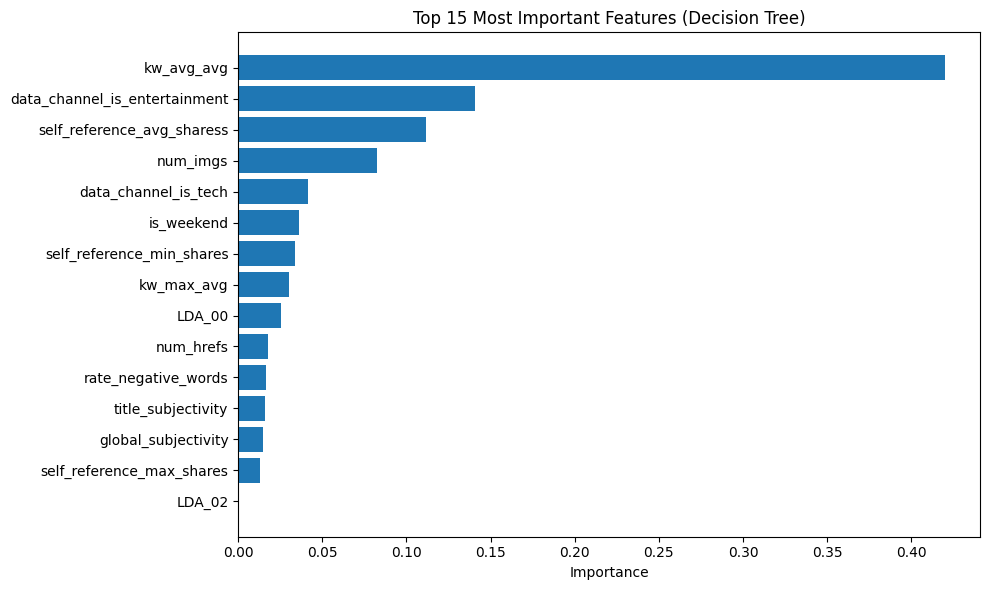

In [13]:
# Get feature importance from Decision Tree
feature_importance = dt_model.featureImportances.toArray()

# Create DataFrame with feature names and importance
importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

print("\nTop 15 Most Important Features (Decision Tree):")
print(importance_df.head(15).to_string(index=False))

# Visualize top 15 features
plt.figure(figsize=(10, 6))
top_features = importance_df.head(15)
plt.barh(range(len(top_features)), top_features['Importance'])
plt.yticks(range(len(top_features)), top_features['Feature'])
plt.xlabel('Importance')
plt.title('Top 15 Most Important Features (Decision Tree)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 9. Model Comparison and Visualization


MODEL COMPARISON - Part 1 (3 CFU)
              Model      AUC  Accuracy  F1-Score  Precision   Recall
Logistic Regression 0.706655  0.652800  0.650108   0.659096 0.652800
        Naive Bayes 0.481182  0.604133  0.576520   0.619499 0.604133
      Decision Tree 0.584417  0.586911  0.586950   0.589861 0.586911


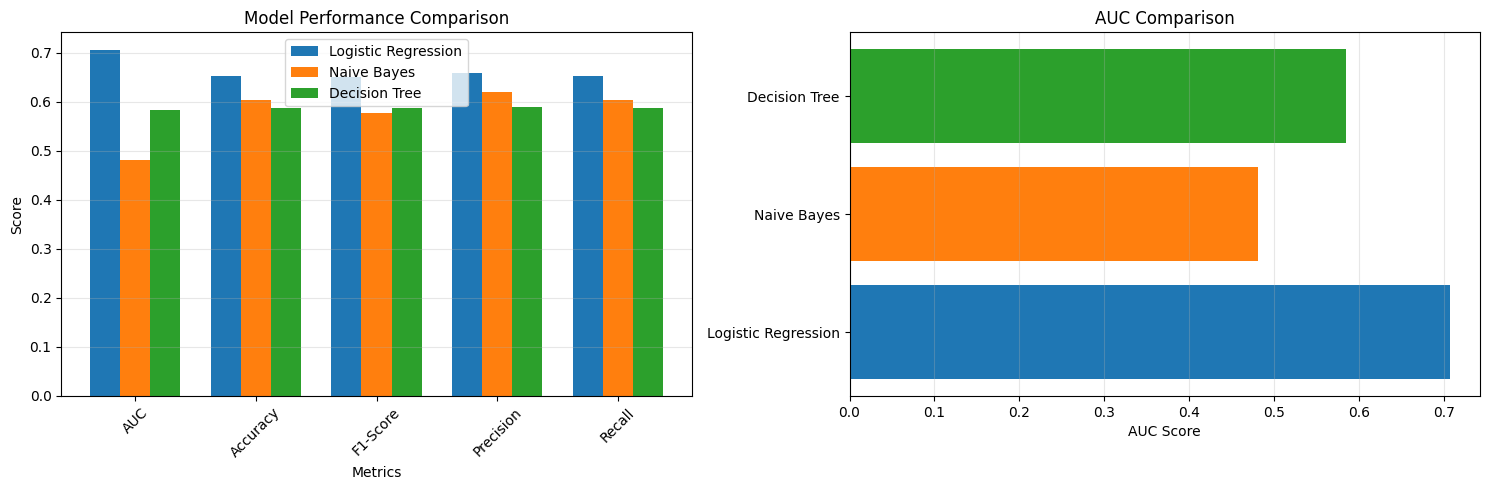

In [14]:
# Create comparison table
comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Naive Bayes', 'Decision Tree'],
    'AUC': [lr_metrics['AUC'], nb_metrics['AUC'], dt_metrics['AUC']],
    'Accuracy': [lr_metrics['Accuracy'], nb_metrics['Accuracy'], dt_metrics['Accuracy']],
    'F1-Score': [lr_metrics['F1-Score'], nb_metrics['F1-Score'], dt_metrics['F1-Score']],
    'Precision': [lr_metrics['Precision'], nb_metrics['Precision'], dt_metrics['Precision']],
    'Recall': [lr_metrics['Recall'], nb_metrics['Recall'], dt_metrics['Recall']]
})

print("\n" + "="*80)
print("MODEL COMPARISON - Part 1 (3 CFU)")
print("="*80)
print(comparison_df.to_string(index=False))

# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Bar chart for all metrics
metrics_to_plot = ['AUC', 'Accuracy', 'F1-Score', 'Precision', 'Recall']
x = np.arange(len(metrics_to_plot))
width = 0.25

for i, model in enumerate(['Logistic Regression', 'Naive Bayes', 'Decision Tree']):
    values = [comparison_df.loc[comparison_df['Model'] == model, metric].values[0] for metric in metrics_to_plot]
    axes[0].bar(x + i*width, values, width, label=model)

axes[0].set_xlabel('Metrics')
axes[0].set_ylabel('Score')
axes[0].set_title('Model Performance Comparison')
axes[0].set_xticks(x + width)
axes[0].set_xticklabels(metrics_to_plot, rotation=45)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# AUC comparison
models = comparison_df['Model']
aucs = comparison_df['AUC']
axes[1].barh(models, aucs, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[1].set_xlabel('AUC Score')
axes[1].set_title('AUC Comparison')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## 10. ROC Curves

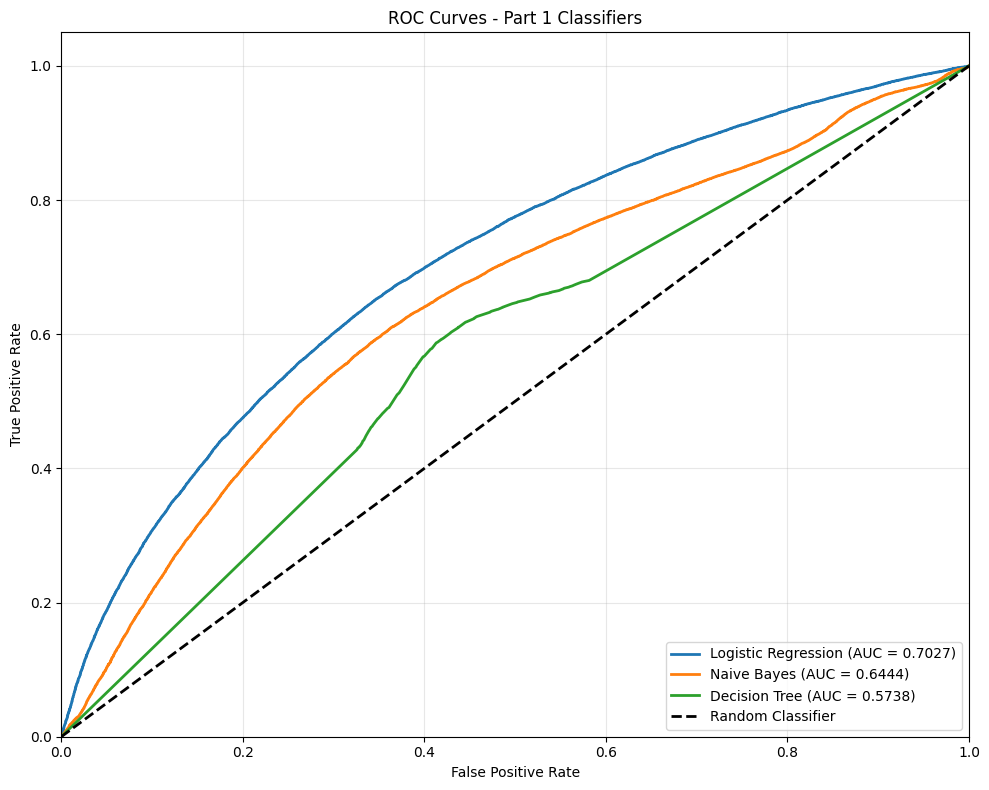

In [15]:
# Plot ROC curves for all models
plt.figure(figsize=(10, 8))

# Combine predictions from all windows for each model
models_data = [
    ('Logistic Regression', lr_predictions, '#1f77b4'),
    ('Naive Bayes', nb_predictions, '#ff7f0e'),
    ('Decision Tree', dt_predictions, '#2ca02c')
]

for model_name, predictions_list, color in models_data:
    # Combine all windows
    all_labels = []
    all_probs = []
    
    for pred_df in predictions_list:
        all_labels.extend(pred_df['label'].values)
        # Extract probability for positive class (index 1)
        probs = [p[1] if len(p) > 1 else p[0] for p in pred_df['probability'].values]
        all_probs.extend(probs)
    
    # Calculate ROC curve
    fpr, tpr, _ = roc_curve(all_labels, all_probs)
    roc_auc = auc(fpr, tpr)
    
    # Plot
    plt.plot(fpr, tpr, color=color, lw=2, 
             label=f'{model_name} (AUC = {roc_auc:.4f})')

# Plot diagonal line
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Part 1 Classifiers')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 11. Summary and Conclusions